<a href="https://colab.research.google.com/github/harikrishna376/dog-vs-cat-prediction/blob/main/cat_vs_dog(image_prediction).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Setting up Kaggle and Downloading the Dataset**

In [ ]:
import os

# Using the username 'krishna12hari' from your Kaggle settings screenshot
os.environ['KAGGLE_USERNAME'] = "krishna12hari"
os.environ['KAGGLE_KEY'] = "KGAT_e140d629d817786a6ee2d38da4f10d33"

# Now try the download again
!kaggle datasets download -d salader/dogsvscats
!unzip -q dogsvscats.zip

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
 98% 1.04G/1.06G [00:05<00:00, 168MB/s]
100% 1.06G/1.06G [00:05<00:00, 205MB/s]


**Preparing the Data for the Neural Network**

****

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

# Create training dataset
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/train',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256)
)

# Create validation dataset
validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/test',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256)
)

# Normalize pixel values to be between 0 and 1
def process(image,label):
    image = tf.cast(image/255. ,tf.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


**Building the Improved Convolutional Neural Network (CNN) Model
**

In [ ]:
model = Sequential()

# New: Explicitly define the input shape
model.add(keras.Input(shape=(256,256,3)))

# Layer 1
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

# Layer 2
model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

# Layer 3
model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

**Training the Model**

In [ ]:
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.6026 - loss: 1.4083 - val_accuracy: 0.6834 - val_loss: 0.5962
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.6995 - loss: 0.5730 - val_accuracy: 0.7102 - val_loss: 0.5509
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.7510 - loss: 0.5095 - val_accuracy: 0.7428 - val_loss: 0.5484
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.7854 - loss: 0.4540 - val_accuracy: 0.5824 - val_loss: 0.7969
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.8244 - loss: 0.3882 - val_accuracy: 0.7932 - val_loss: 0.4759
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.8586 - loss: 0.3272 - val_accuracy: 0.7560 - val_loss: 0.4896
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.8977 - loss: 0.2438 - val_accuracy: 0.7884 - val_loss: 0.5099
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.9329 - loss: 0.1712 - 

**Visualizing Training Progress (Accuracy and Loss)**

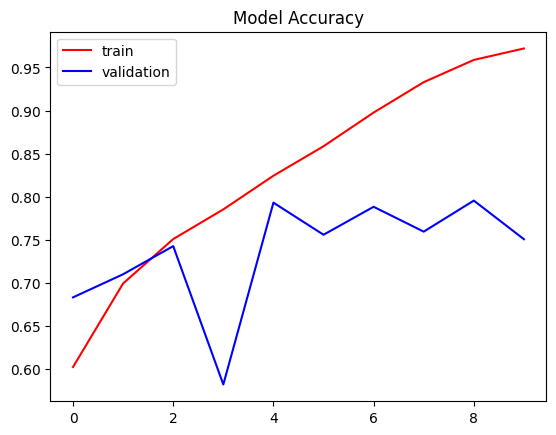

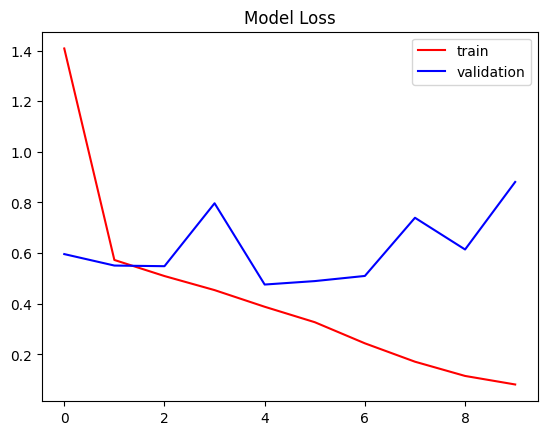

In [ ]:
import matplotlib.pyplot as plt

# Plotting Accuracy
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.legend()
plt.show()

# Plotting Loss
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.legend()
plt.show()

**Testing the Model with a New Image**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
It's a DOG!


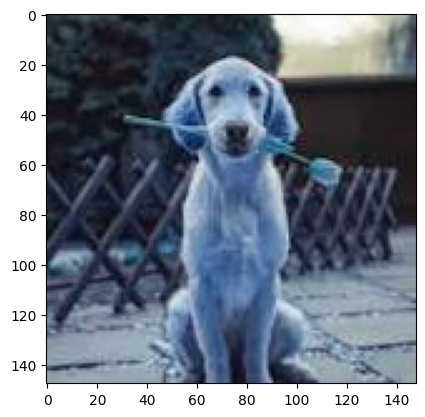

In [ ]:
import cv2

# 1. Load the image
test_img = cv2.imread('/content/my_image.jpg')
plt.imshow(test_img)

# 2. Resize and Preprocess
test_img = cv2.resize(test_img,(256,256))
test_input = test_img.reshape((1,256,256,3)) / 255.0

# 3. Predict
result = model.predict(test_input)

if result[0][0] > 0.5:
    print("It's a DOG!")
else:
    print("It's a CAT!")

optimization

In [ ]:
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

model = Sequential()

# Layer 1
model.add(keras.Input(shape=(256,256,3)))
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization()) # Added to stabilize training
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

# Layer 2
model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization()) # Added to stabilize training
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

# Layer 3
model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization()) # Added to stabilize training
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

# Fully Connected Layers with Dropout
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1)) # Randomly shuts off 10% of neurons to prevent memorization
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1)) # Prevents overfitting
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# This will take 10-15 minutes on a T4 GPU
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.5642 - loss: 1.3466 - val_accuracy: 0.6104 - val_loss: 0.6500
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 89ms/step - accuracy: 0.6309 - loss: 0.6265 - val_accuracy: 0.7118 - val_loss: 0.5732
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 91ms/step - accuracy: 0.6979 - loss: 0.5552 - val_accuracy: 0.6610 - val_loss: 0.5881
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.7449 - loss: 0.4841 - val_accuracy: 0.7716 - val_loss: 0.4793
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.7876 - loss: 0.4129 - val_accuracy: 0.6760 - val_loss: 0.5425
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.8117 - loss: 0.3658 - val_accuracy: 0.7532 - val_loss: 0.4629
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.8328 - loss: 0.3118 - val_accuracy: 0.7586 - val_loss: 0.5026
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.8521 - loss: 0.2701 - 

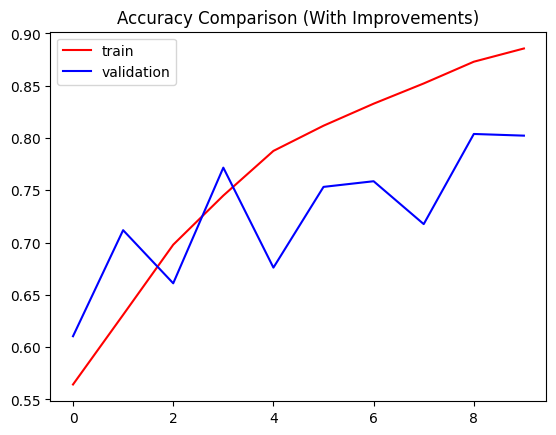

In [ ]:
import matplotlib.pyplot as plt

# Compare Training vs Validation Accuracy
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Accuracy Comparison (With Improvements)')
plt.legend()
plt.show()

 ** saving model**

In [ ]:
# Save in the new recommended format
model.save('cat_dog_model.keras')

# Download the new file
from google.colab import files
files.download('cat_dog_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>